#Regional Marketing Analysis

## tl;dr

For the current customer snapshot dated **2026-07-08**, repeat customers are approximately **53% of customers but contribute about 94% of recorded lifetime spend**. The strongest addressable groups are active repeat customers, 2,251 at-risk high-value customers, and 1,744 recent one-time customers. Use controlled tests; the modeled revenue and gross-profit values are scenarios, not forecasts.

## Decision

Prioritize customer groups and campaign motions that can increase repeat purchasing and protect lifetime value without relying on indiscriminate discounts.

## Context & methods

The unit of analysis is one customer export record. Monetary values are historical lifetime spend. Recency is measured from the latest `last_active` date in the export. No product, campaign-spend, contact-consent or response data is available.

### 1. Setup and locate the analysis-ready file

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

COLORS = {
    "blue": "#35648F",
    "gold": "#C89B32",
    "orange": "#CC6B3D",
    "olive": "#7F8C55",
    "ink": "#2F3742",
    "grey": "#AAB4BF",
    "light": "#E7ECF1",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "axes.titlecolor": COLORS["ink"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "text.color": COLORS["ink"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "#D7DCE1",
    "grid.alpha": 0.75,
    "grid.linewidth": 0.8,
})

def find_data_file() -> Path:
    candidates = []
    configured = os.environ.get("CANADA_VAPES_ANALYSIS_FILE")
    if configured:
        candidates.append(Path(configured))
    candidates.extend([
        Path.cwd() / "CanadaVapes_analysis_ready.csv",
        Path.cwd() / "upload" / "CanadaVapes_analysis_ready.csv",
        Path("C:/Users/tooko/Downloads/canadavape/CanadaVapes_analysis_ready.csv"),
        Path("C:/Users/tooko/Downloads/canada vape/CanadaVapes_analysis_ready.csv"),
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    checked = "\n".join(f"  - {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        "CanadaVapes_analysis_ready.csv was not found. Checked:\n" + checked
    )

DATA_FILE = find_data_file()
BASE_OUTPUT_FOLDER = DATA_FILE.parent / "CanadaVapes_strategic_outputs"
BASE_OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

def money(value: float) -> str:
    return f"${value:,.0f}"

def percent(value: float) -> str:
    return f"{value:.1%}"

def finish_axis(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

print("Analysis-ready data:", DATA_FILE)
print("Output folder:", BASE_OUTPUT_FOLDER)

Analysis-ready data: C:\Users\tooko\Downloads\regional_analysis_ready.csv
Output folder: C:\Users\tooko\Downloads\regional_strategic_outputs


### 2. Load and validate customer data

In [2]:
required_columns = {
    "customer_record_id", "last_active", "sign_up", "orders", "total_spend",
    "aov", "city", "region", "days_since_last_active",
    "customer_tenure_days", "record_quality_status", "data_quality_issue",
}

df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig",
    parse_dates=["last_active", "sign_up"],
)

missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError("Required columns are missing: " + ", ".join(missing_columns))

for column in ["orders", "total_spend", "aov", "days_since_last_active", "customer_tenure_days"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

if df["customer_record_id"].duplicated().any():
    raise ValueError("customer_record_id is not unique.")
if df[["orders", "total_spend", "aov", "days_since_last_active"]].isna().any().any():
    raise ValueError("Core analysis fields contain missing or invalid numbers.")
if (df[["orders", "total_spend", "aov"]].lt(0)).any().any():
    raise ValueError("The analysis-ready file still contains negative core values.")

snapshot_date = df["last_active"].max().normalize()
df["is_repeat_customer"] = df["orders"].ge(2)
df["is_active_90d"] = df["days_since_last_active"].le(90)

print(f"Rows loaded: {len(df):,}")
print(f"Snapshot date: {snapshot_date.date()}")
display(df[[
    "customer_record_id", "last_active", "orders", "total_spend", "aov",
    "city", "region", "days_since_last_active"
]].head())

Rows loaded: 30,803
Snapshot date: 2026-07-08


,customer_record_id,last_active,orders,total_spend,aov,city,region,days_since_last_active
0,CV-000001,2026-07-08 15:31:03,11,"1,140.69",103.70,Neuville,QC,0
1,CV-000002,2026-07-08 15:29:52,54,"8,902.99",164.87,Niagara Falls,ON,0
2,CV-000003,2026-07-08 15:28:42,18,"2,713.19",150.73,Glencoe,ON,0
3,CV-000004,2026-07-08 15:28:26,2,180.64,90.32,Laval,QC,0
4,CV-000005,2026-07-08 15:26:59,49,"6,284.21",128.25,Port Medway,NS,0


### 3. Create actionable customer segments

In [3]:
MARKETING_FOLDER = BASE_OUTPUT_FOLDER / "marketing"
MARKETING_FOLDER.mkdir(parents=True, exist_ok=True)

frequency_q75 = float(df["orders"].quantile(0.75))
monetary_median = float(df["total_spend"].median())
monetary_q75 = float(df["total_spend"].quantile(0.75))

recency = df["days_since_last_active"]
frequency = df["orders"]
monetary = df["total_spend"]
tenure = df["customer_tenure_days"]

conditions = [
    recency.le(30) & frequency.ge(frequency_q75) & monetary.ge(monetary_q75),
    recency.le(90) & frequency.ge(2) & monetary.ge(monetary_median),
    tenure.le(90) & frequency.eq(1) & recency.le(90),
    recency.le(90) & frequency.ge(2),
    recency.le(90) & frequency.eq(1),
    recency.between(91, 365) & (frequency.ge(frequency_q75) | monetary.ge(monetary_q75)),
    recency.gt(365) & (frequency.ge(frequency_q75) | monetary.ge(monetary_q75)),
    recency.gt(365),
]

segment_names = [
    "Champions", "Loyal high value", "New high potential", "Active repeat",
    "Recent one-time", "At-risk high value", "Dormant high value",
    "Dormant low value",
]

df["marketing_segment"] = np.select(
    conditions,
    segment_names,
    default="Needs attention",
)

segment_summary = (
    df.groupby("marketing_segment", as_index=False)
    .agg(
        customers=("customer_record_id", "size"),
        lifetime_spend=("total_spend", "sum"),
        average_lifetime_spend=("total_spend", "mean"),
        median_aov=("aov", "median"),
        total_orders=("orders", "sum"),
        median_recency_days=("days_since_last_active", "median"),
    )
)
segment_summary["customer_share"] = segment_summary["customers"] / len(df)
segment_summary["spend_share"] = segment_summary["lifetime_spend"] / df["total_spend"].sum()
segment_summary = segment_summary.sort_values("lifetime_spend", ascending=False)

df.to_csv(MARKETING_FOLDER / "marketing_customer_segments.csv", index=False, encoding="utf-8-sig")
segment_summary.to_csv(MARKETING_FOLDER / "marketing_segment_summary.csv", index=False, encoding="utf-8-sig")
display(segment_summary)

,marketing_segment,customers,lifetime_spend,average_lifetime_spend,median_aov,total_orders,median_recency_days,customer_share,spend_share
2,Champions,2412,"8,113,363.04","3,363.75",122.25,57196,12.00,0.08,0.39
5,Loyal high value,3068,"4,230,506.45","1,378.91",104.82,30415,44.00,0.10,0.20
1,At-risk high value,2251,"3,215,681.39","1,428.56",106.02,24828,206.00,0.07,0.16
3,Dormant high value,2112,"2,552,584.53","1,208.61",99.25,22046,418.00,0.07,0.12
4,Dormant low value,12530,"1,518,262.82",121.17,72.98,18157,499.00,0.41,0.07
6,Needs attention,6340,"897,117.17",141.50,79.07,10230,215.00,0.21,0.04
7,New high potential,1594,"151,891.16",95.29,80.41,1594,43.00,0.05,0.01
0,Active repeat,346,"40,825.58",117.99,59.94,742,36.50,0.01,0.00
8,Recent one-time,150,"14,659.76",97.73,81.46,150,40.50,0.00,0.00


### 4. Compare segment reach and historical value

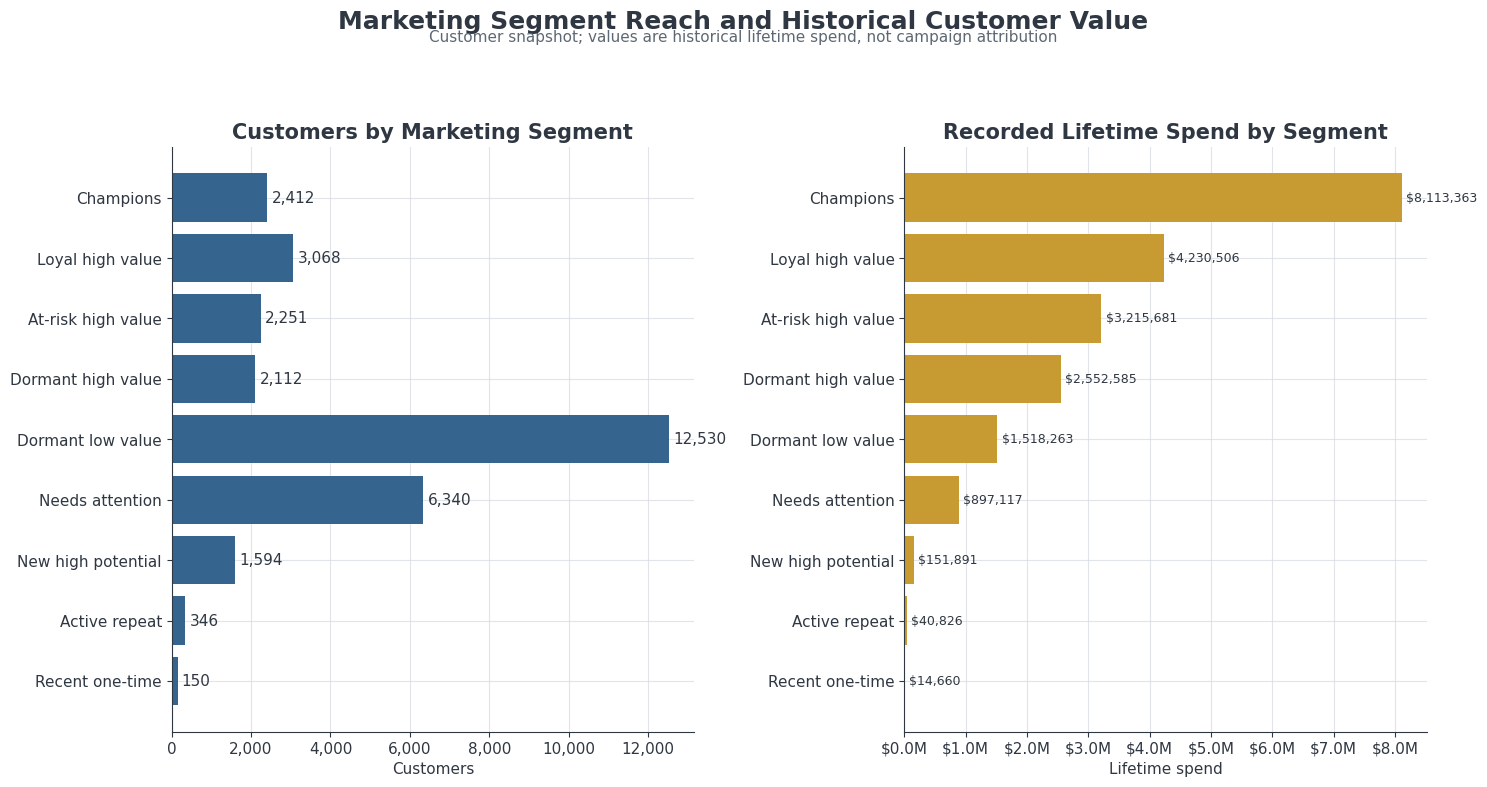

In [4]:
plot_data = segment_summary.sort_values("lifetime_spend", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].barh(plot_data["marketing_segment"], plot_data["customers"], color=COLORS["blue"])
axes[0].set_title("Customers by Marketing Segment")
axes[0].set_xlabel("Customers")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="{:,.0f}", padding=3)
finish_axis(axes[0])

axes[1].barh(plot_data["marketing_segment"], plot_data["lifetime_spend"], color=COLORS["gold"])
axes[1].set_title("Recorded Lifetime Spend by Segment")
axes[1].set_xlabel("Lifetime spend")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
for container in axes[1].containers:
    axes[1].bar_label(container, labels=[money(v) for v in plot_data["lifetime_spend"]], padding=3, fontsize=9)
finish_axis(axes[1])

fig.suptitle("Marketing Segment Reach and Historical Customer Value", fontsize=18, fontweight="bold")
fig.text(0.5, 0.94, "Customer snapshot; values are historical lifetime spend, not campaign attribution", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0, 1, 0.91])
CHART_FILE = MARKETING_FOLDER / "01_segment_reach_and_value.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 5. Locate the recency-value opportunity

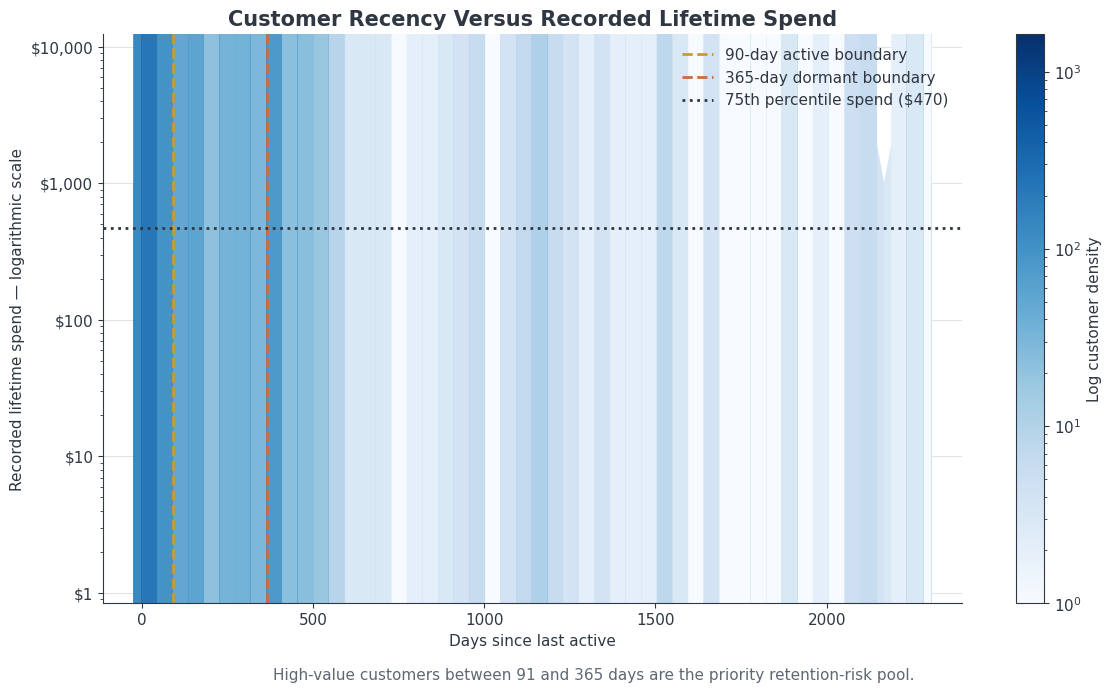

In [5]:
scatter_data = df.loc[df["total_spend"].gt(0), ["days_since_last_active", "total_spend"]].copy()
scatter_data["days_since_last_active"] = scatter_data["days_since_last_active"].clip(upper=scatter_data["days_since_last_active"].quantile(0.99))
scatter_data["total_spend"] = scatter_data["total_spend"].clip(upper=scatter_data["total_spend"].quantile(0.99))

fig, ax = plt.subplots(figsize=(12, 7))
hex_plot = ax.hexbin(
    scatter_data["days_since_last_active"],
    scatter_data["total_spend"],
    gridsize=50,
    bins="log",
    mincnt=1,
    cmap="Blues",
)
ax.set_yscale("log")
ax.axvline(90, color=COLORS["gold"], linestyle="--", linewidth=2, label="90-day active boundary")
ax.axvline(365, color=COLORS["orange"], linestyle="--", linewidth=2, label="365-day dormant boundary")
ax.axhline(monetary_q75, color=COLORS["ink"], linestyle=":", linewidth=2, label=f"75th percentile spend ({money(monetary_q75)})")
ax.set_title("Customer Recency Versus Recorded Lifetime Spend")
ax.set_xlabel("Days since last active")
ax.set_ylabel("Recorded lifetime spend — logarithmic scale")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(frameon=False, loc="upper right")
colorbar = fig.colorbar(hex_plot, ax=ax)
colorbar.set_label("Log customer density")
finish_axis(ax)
fig.text(0.5, 0.02, "High-value customers between 91 and 365 days are the priority retention-risk pool.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = MARKETING_FOLDER / "02_recency_value_density.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 6. Compare geographic reach and customer quality

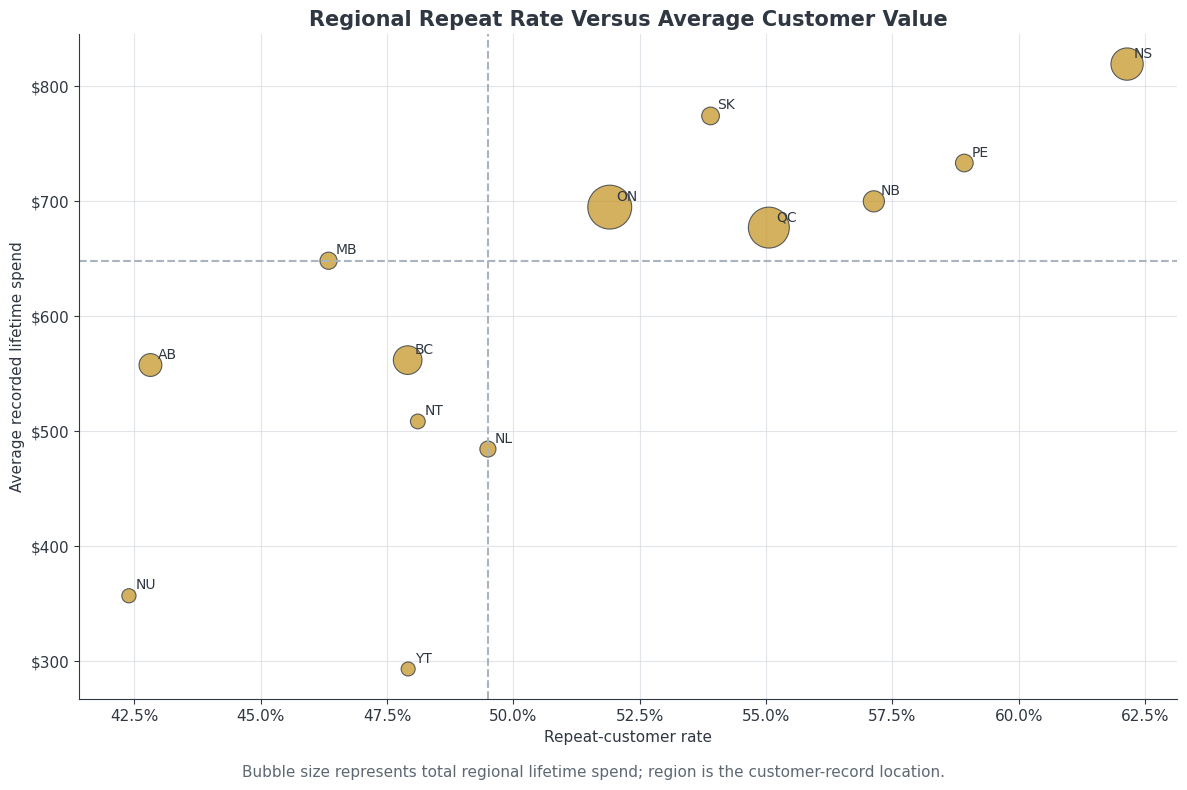

In [6]:
region_marketing = (
    df.dropna(subset=["region"])
    .groupby("region", as_index=False)
    .agg(
        customers=("customer_record_id", "size"),
        lifetime_spend=("total_spend", "sum"),
        average_lifetime_spend=("total_spend", "mean"),
        repeat_rate=("is_repeat_customer", "mean"),
        active_90d_rate=("is_active_90d", "mean"),
    )
)
region_marketing.to_csv(MARKETING_FOLDER / "marketing_region_summary.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(12, 8))
sizes = 100 + 900 * region_marketing["lifetime_spend"] / region_marketing["lifetime_spend"].max()
ax.scatter(
    region_marketing["repeat_rate"],
    region_marketing["average_lifetime_spend"],
    s=sizes,
    color=COLORS["gold"],
    edgecolor=COLORS["ink"],
    linewidth=0.8,
    alpha=0.78,
)
for row in region_marketing.itertuples():
    ax.annotate(row.region, (row.repeat_rate, row.average_lifetime_spend), xytext=(5, 5), textcoords="offset points", fontsize=10)
ax.axvline(region_marketing["repeat_rate"].median(), color=COLORS["grey"], linestyle="--")
ax.axhline(region_marketing["average_lifetime_spend"].median(), color=COLORS["grey"], linestyle="--")
ax.set_title("Regional Repeat Rate Versus Average Customer Value")
ax.set_xlabel("Repeat-customer rate")
ax.set_ylabel("Average recorded lifetime spend")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
finish_axis(ax)
fig.text(0.5, 0.02, "Bubble size represents total regional lifetime spend; region is the customer-record location.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = MARKETING_FOLDER / "03_region_reach_and_quality.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 7. Size campaign scenarios and export target lists

In [7]:
GROSS_MARGIN_ASSUMPTION = 0.35
CONTACT_COST_ASSUMPTION = 1.50

campaign_definitions = [
    {
        "campaign": "Active repeat value expansion",
        "mask": df["days_since_last_active"].le(90) & df["orders"].ge(2),
        "response_rate": 0.10,
        "action": "Personalized replenishment or loyalty message; no blanket discount",
    },
    {
        "campaign": "At-risk high-value retention",
        "mask": df["days_since_last_active"].between(91, 365)
        & (df["orders"].ge(frequency_q75) | df["total_spend"].ge(monetary_q75)),
        "response_rate": 0.08,
        "action": "Personalized win-back with a holdout group",
    },
    {
        "campaign": "Recent one-time second purchase",
        "mask": df["days_since_last_active"].le(90) & df["orders"].eq(1),
        "response_rate": 0.10,
        "action": "Education and reorder reminder before any incentive",
    },
    {
        "campaign": "Dormant high-value reactivation",
        "mask": df["days_since_last_active"].gt(365)
        & (df["orders"].ge(frequency_q75) | df["total_spend"].ge(monetary_q75)),
        "response_rate": 0.05,
        "action": "Low-cost repermission or reactivation test",
    },
]

scenario_rows = []
target_frames = []
for definition in campaign_definitions:
    target = df.loc[definition["mask"]].copy()
    target["campaign"] = definition["campaign"]
    target_frames.append(target[[
        "campaign", "customer_record_id", "marketing_segment", "region", "city",
        "orders", "total_spend", "aov", "days_since_last_active"
    ]])
    target_customers = len(target)
    expected_order_value = float(target["aov"].median()) if target_customers else 0.0
    modeled_orders = target_customers * definition["response_rate"]
    modeled_revenue = modeled_orders * expected_order_value
    modeled_profit = modeled_revenue * GROSS_MARGIN_ASSUMPTION - target_customers * CONTACT_COST_ASSUMPTION
    scenario_rows.append({
        "campaign": definition["campaign"],
        "target_customers": target_customers,
        "assumed_response_rate": definition["response_rate"],
        "median_aov": expected_order_value,
        "modeled_incremental_revenue": modeled_revenue,
        "modeled_incremental_gross_profit": modeled_profit,
        "recommended_action": definition["action"],
    })

campaign_summary = pd.DataFrame(scenario_rows).sort_values("modeled_incremental_gross_profit", ascending=False)
campaign_targets = pd.concat(target_frames, ignore_index=True)
campaign_summary.to_csv(MARKETING_FOLDER / "marketing_campaign_scenarios.csv", index=False, encoding="utf-8-sig")
campaign_targets.to_csv(MARKETING_FOLDER / "marketing_campaign_targets.csv", index=False, encoding="utf-8-sig")
display(campaign_summary)

,campaign,target_customers,assumed_response_rate,median_aov,modeled_incremental_revenue,modeled_incremental_gross_profit,recommended_action
0,Active repeat value expansion,5826,0.10,108.61,"63,273.27","13,406.65",Personalized replenishment or loyalty message;...
1,At-risk high-value retention,2251,0.08,106.02,"19,092.08","3,305.73",Personalized win-back with a holdout group
2,Recent one-time second purchase,1744,0.10,80.46,"14,032.22","2,295.28",Education and reorder reminder before any ince...
3,Dormant high-value reactivation,2112,0.05,99.25,"10,480.80",500.28,Low-cost repermission or reactivation test


### 8. Visualize modeled campaign economics

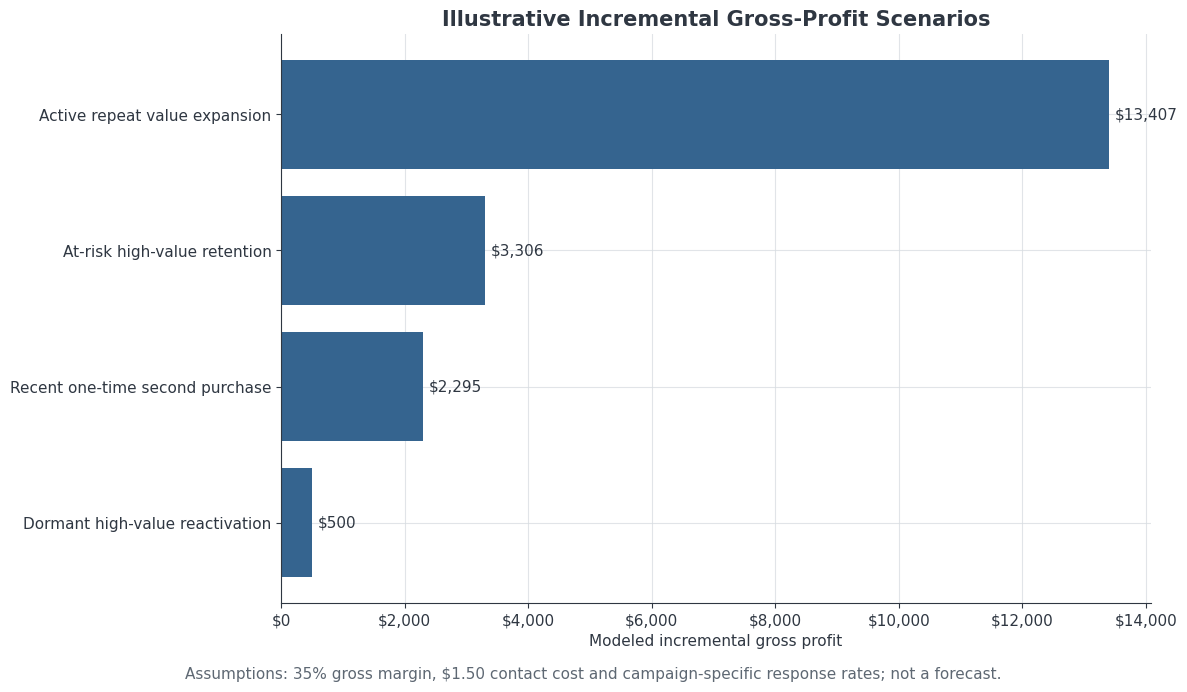

In [8]:
scenario_plot = campaign_summary.sort_values("modeled_incremental_gross_profit", ascending=True)
colors = [COLORS["orange"] if value < 0 else COLORS["blue"] for value in scenario_plot["modeled_incremental_gross_profit"]]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(scenario_plot["campaign"], scenario_plot["modeled_incremental_gross_profit"], color=colors)
ax.axvline(0, color=COLORS["ink"], linewidth=1.2)
ax.set_title("Illustrative Incremental Gross-Profit Scenarios")
ax.set_xlabel("Modeled incremental gross profit")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.bar_label(bars, labels=[money(v) for v in scenario_plot["modeled_incremental_gross_profit"]], padding=4)
finish_axis(ax)
fig.text(0.5, 0.02, "Assumptions: 35% gross margin, $1.50 contact cost and campaign-specific response rates; not a forecast.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = MARKETING_FOLDER / "04_campaign_profit_scenarios.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Strategic recommendations

In [9]:
repeat_customer_share = df["is_repeat_customer"].mean()
repeat_spend_share = df.loc[df["is_repeat_customer"], "total_spend"].sum() / df["total_spend"].sum()
at_risk_row = segment_summary.loc[segment_summary["marketing_segment"].eq("At-risk high value")].iloc[0]

marketing_recommendations = pd.DataFrame([
    {
        "priority": 1,
        "recommendation": "Protect and expand the repeat-customer base",
        "evidence": f"Repeat customers are {repeat_customer_share:.1%} of customers and {repeat_spend_share:.1%} of lifetime spend.",
        "measurement": "Incremental gross profit and repeat order rate versus a 10–20% holdout",
    },
    {
        "priority": 2,
        "recommendation": "Run a high-value retention test before broad reactivation",
        "evidence": f"{int(at_risk_row['customers']):,} at-risk high-value records represent {money(at_risk_row['lifetime_spend'])} of historical spend.",
        "measurement": "90-day incremental revenue, gross profit, unsubscribe rate and reactivation rate",
    },
    {
        "priority": 3,
        "recommendation": "Create a structured first-to-second-purchase journey",
        "evidence": f"{int((df['orders'].eq(1) & df['days_since_last_active'].le(90)).sum()):,} recent one-time records are addressable.",
        "measurement": "Second-purchase conversion within 30, 60 and 90 days",
    },
    {
        "priority": 4,
        "recommendation": "Improve targeting data before channel-budget allocation",
        "evidence": "This customer snapshot has no campaign source, spend, consent, product or response fields.",
        "measurement": "UTM coverage, consent coverage, campaign cost and holdout assignment completeness",
    },
])
marketing_recommendations.to_csv(MARKETING_FOLDER / "marketing_strategic_recommendations.csv", index=False, encoding="utf-8-sig")
display(marketing_recommendations)

,priority,recommendation,evidence,measurement
0,1,Protect and expand the repeat-customer base,Repeat customers are 53.0% of customers and 93...,Incremental gross profit and repeat order rate...
1,2,Run a high-value retention test before broad r...,"2,251 at-risk high-value records represent $3,...","90-day incremental revenue, gross profit, unsu..."
2,3,Create a structured first-to-second-purchase j...,"1,744 recent one-time records are addressable.","Second-purchase conversion within 30, 60 and 9..."
3,4,Improve targeting data before channel-budget a...,"This customer snapshot has no campaign source,...","UTM coverage, consent coverage, campaign cost ..."


## Validation and limitations

In [10]:
assert len(df) == int(segment_summary["customers"].sum())
assert np.isclose(df["total_spend"].sum(), segment_summary["lifetime_spend"].sum())
assert campaign_summary["target_customers"].gt(0).all()
assert (MARKETING_FOLDER / "marketing_campaign_targets.csv").exists()

validation = pd.DataFrame({
    "check": ["Customer reconciliation", "Lifetime-spend reconciliation", "Campaign targets created", "Notebook scope"],
    "result": ["Passed", "Passed", "Passed", "Customer snapshot; scenarios are not causal forecasts"],
})
display(validation)

,check,result
0,Customer reconciliation,Passed
1,Lifetime-spend reconciliation,Passed
2,Campaign targets created,Passed
3,Notebook scope,Customer snapshot; scenarios are not causal fo...
